In [1]:
import os
import sys
import random
import bentoml
import numpy as np
import pandas as pd
import pprint as pp
from pathlib import Path

# 현재 노트북이 있는 경로 기준으로 프로젝트 루트(recsys) 경로 계산
current_dir = (
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in globals()
    else os.getcwd()
)
project_root = os.path.abspath(os.path.join(current_dir, ".."))

# recsys 폴더를 sys.path에 추가
if project_root not in sys.path:
    sys.path.append(project_root)

from setup_env import setup_env

root_dir = setup_env()

from models.transformer.preprocess import SequenceGenerator
from utils.dataset.config import DatasetPath
from utils.dataset.plot import show_items
from models.transformer.model import Model
from utils.retriever.ann import build_index, search

device = "cpu"

[INFO] Font applied: NanumGothic


# Load Dataset

In [2]:
# 데이터셋 경로
dataset_dir = Path(root_dir).joinpath("data/dataset")
paths = DatasetPath(root_dir=dataset_dir, dataset_name="fashion")

df_item = pd.read_parquet(paths.item_metadata_path)
df_user_logs = pd.read_parquet(paths.user_logs_path)
df_user_logs.head()

,user_id,item_id,timestamp,action,age,gender,name,brand_name,price,discount_price,...,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,description
0,1,3118,2025-10-21 03:01:00,click,46,Men,John Miller Men Check Pink Shirt,John Miller,999.0,999.0,...,Pink,Summer,2012,Formal,Apparel,Topwear,Shirts,Regular Fit,<UNK>,<p><strong>Composition</strong><br />Pink and ...
1,1,2858,2025-10-21 03:02:00,click,46,Men,John Miller Men Striped Blue Shirt,John Miller,899.0,899.0,...,Blue,Summer,2012,Formal,Apparel,Topwear,Shirts,Regular Fit,<UNK>,<p><strong>Composition</strong><br /> Blue and...
2,1,1912,2025-10-21 03:05:00,click,46,Men,Black Coffee Men White Shirt,Black coffee,974.0,974.0,...,White,Summer,2012,Formal,Apparel,Topwear,Shirts,Regular Fit,Formal,<p>White formal shirt that has a spread collar...
3,1,8797,2025-10-21 03:04:00,click,46,Men,John Miller Men Striped Black Shirt,John Miller,799.0,799.0,...,Black,Summer,2012,Formal,Apparel,Topwear,Shirts,Regular Fit,<UNK>,<p><strong>Composition</strong><br />Black and...
4,1,1574,2025-10-21 03:17:00,click,46,Men,John Miller Men Check Black Shirt,John Miller,899.0,899.0,...,Black,Summer,2012,Formal,Apparel,Topwear,Shirts,Regular Fit,<UNK>,"<p>C<span style=""font-style: normal; font-weig..."


# Load Model

In [3]:
# 모델 저장 디렉토리 경로
seq_model_artifact = bentoml.models.get("transformer:latest")
reg_model_artifact = bentoml.models.get("regressor:latest")

seq_model_dir = Path(seq_model_artifact.path_of("artifact"))
reg_model_dir = Path(reg_model_artifact.path_of("artifact"))

# 모델 객체 초기화
model = Model(seq_model_dir=seq_model_dir, reg_model_dir=reg_model_dir)

## Prediction Test

In [4]:
# 학습 데이터셋의 랜덤 유저를 추출하여 시퀀스 샘플 생성
user_id = random.choice(df_user_logs["user_id"].unique())
df_user_sample = df_user_logs[df_user_logs["user_id"] == user_id]
df_user_sample = df_user_sample.sort_values(by="user_id", ignore_index=True)

In [5]:
sequence_generator = SequenceGenerator(max_seq_len=model.seq_model_config["seq_len"])

feature_names = list(model.seq_model_config["feature_dims"].keys()) + ["item_id"]
target_names = list(model.seq_model_config["feature_dims"].keys())

df_seq_sample = sequence_generator.get_seq_dataframe(
    data=df_user_sample, feature_sequences=feature_names
)
df_seq_sample = df_seq_sample[df_seq_sample["seq_len"] == 5]
df_seq_sample

,user_id,user_rn,seq_len,mask,brand_name,gender,age_group,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,action,item_id,y_item_id
1,8130,2,5,"[0, 0, 0, 0, 0]","[Q&Q, Q&Q, Q&Q, ADIDAS, yelloe]","[Girls, Girls, Girls, Unisex, Unisex]","[Kids-Girls, Kids-Girls, Kids-Girls, Adults-Un...","[Yellow, Yellow, White, Black, Cream]","[Winter, Winter, Winter, Summer, Summer]","[2016, 2016, 2016, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Accessories, Accessories, Accessories, Access...","[Watches, Watches, Watches, Bags, Bags]","[Watches, Watches, Watches, Laptop Bag, Laptop...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[click, click, click, click, cart]","[1227, 6885, 7458, 2164, 9152]","[6885, 7458, 2164, 9152, 260]"
3,8130,5,5,"[0, 0, 0, 0, 0]","[Skechers, Nike, Nike, Mod-acc, yelloe]","[Men, Men, Men, Women, Women]","[Adults-Men, Adults-Men, Adults-Men, Adults-Wo...","[Navy Blue, Black, Grey, Black, Pink]","[Summer, Summer, Summer, Summer, Summer]","[2012, 2012, 2012, 2012, 2015]","[Casual, Casual, Casual, Casual, Casual]","[Footwear, Footwear, Footwear, Accessories, Ac...","[Shoes, Shoes, Shoes, Bags, Bags]","[Sports Shoes, Sports Shoes, Sports Shoes, Han...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[click, click, click, click, purchase]","[5264, 2778, 5582, 3501, 134]","[2778, 5582, 3501, 134, 4185]"
4,8130,6,5,"[0, 0, 0, 0, 0]","[Nike, ADIDAS, Skechers, Nike, Nike]","[Men, Men, Men, Men, Men]","[Adults-Men, Adults-Men, Adults-Men, Adults-Me...","[Black, Brown, Navy Blue, Black, Grey]","[Summer, Summer, Summer, Summer, Summer]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Footwear, Footwear, Footwear, Footwear, Footw...","[Shoes, Shoes, Shoes, Shoes, Shoes]","[Sports Shoes, Sports Shoes, Sports Shoes, Spo...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[click, purchase, click, click, click]","[1013, 9099, 5264, 2778, 5582]","[9099, 5264, 2778, 5582, 3501]"
5,8130,7,5,"[0, 0, 0, 0, 0]","[ADIDAS, Skechers, Nike, Nike, Mod-acc]","[Men, Men, Men, Men, Women]","[Adults-Men, Adults-Men, Adults-Men, Adults-Me...","[Brown, Navy Blue, Black, Grey, Black]","[Summer, Summer, Summer, Summer, Summer]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Footwear, Footwear, Footwear, Footwear, Acces...","[Shoes, Shoes, Shoes, Shoes, Bags]","[Sports Shoes, Sports Shoes, Sports Shoes, Spo...","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[<UNK>, <UNK>, <UNK>, <UNK>, <UNK>]","[purchase, click, click, click, click]","[9099, 5264, 2778, 5582, 3501]","[5264, 2778, 5582, 3501, 134]"
6,8130,8,5,"[0, 0, 0, 0, 0]","[ADIDAS, French Connection, Nike, ADIDAS, Skec...","[Men, Men, Men, Men, Men]","[Adults-Men, Adults-Men, Adults-Men, Adults-Me...","[Green, White, Black, Brown, Navy Blue]","[Summer, Summer, Summer, Summer, Summer]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Apparel, Apparel, Footwear, Footwear, Footwear]","[Topwear, Topwear, Shoes, Shoes, Shoes]","[Tshirts, Tshirts, Sports Shoes, Sports Shoes,...","[Slim Fit, Regular Fit, <UNK>, <UNK>, <UNK>]","[<UNK>, Casual, <UNK>, <UNK>, <UNK>]","[click, click, click, purchase, click]","[4581, 5957, 1013, 9099, 5264]","[5957, 1013, 9099, 5264, 2778]"
7,8130,9,5,"[0, 0, 0, 0, 0]","[French Connection, Nike, ADIDAS, Skechers, Nike]","[Men, Men, Men, Men, Men]","[Adults-Men, Adults-Men, Adults-Men, Adults-Me...","[White, Black, Brown, Navy Blue, Black]","[Summer, Summer, Summer, Summer, Summer]","[2012, 2012, 2012, 2012, 2012]","[Casual, Casual, Casual, Casual, Casual]","[Apparel, Footwear, Footwear, Footwear, Footwear]","[Topwear, Shoes, Shoes, Shoes, Shoes]","[Tshirts, Sports Shoes, Sports Shoes, Sports S...","[Regular Fit, <UNK>, <UNK>, <UNK>, <UNK>]","[Casual, <UNK>, <UNK>, <UNK>, <UNK>]","[click, click, purchase, click, click]","[5957, 1013, 9099, 5264, 2778]","[1013, 

In [6]:
seq_sample = df_seq_sample.sample(1).to_dict(orient="records")[0]
seq_sample

{'user_id': 8130,
 'user_rn': 21,
 'seq_len': 5,
 'mask': [0, 0, 0, 0, 0],
 'brand_name': ['Lino Perros', 'BULCHEE', 'Hop Scotch', 'Q&Q', 'Chhota Bheem'],
 'gender': ['Women', 'Women', 'Girls', 'Girls', 'Girls'],
 'age_group': ['Adults-Women',
  'Adults-Women',
  'Kids-Girls',
  'Kids-Girls',
  'Kids-Girls'],
 'base_color': ['Black', 'Black', 'Pink', 'White', 'Pink'],
 'season': ['Summer', 'Summer', 'Winter', 'Winter', 'Winter'],
 'year': ['2012', '2012', '2016', '2016', '2016'],
 'usage': ['Casual', 'Casual', 'Casual', 'Casual', 'Casual'],
 'master_category': ['Accessories',
  'Accessories',
  'Accessories',
  'Accessories',
  'Accessories'],
 'sub_category': ['Bags', 'Bags', 'Watches', 'Watches', 'Watches'],
 'article_type': ['Handbags', 'Handbags', 'Watches', 'Watches', 'Watches'],
 'fit': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'occasion': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', 'Casual'],
 'action': ['click', 'click', 'click', 'click', 'click'],
 'item_id': [7880, 5812, 4675,

In [7]:
inputs = {}
for k in model.seq_model_config["feature_dims"].keys():
    inputs[k] = seq_sample[k]

pp.pprint(inputs)

{'action': ['click', 'click', 'click', 'click', 'click'],
 'age_group': ['Adults-Women',
               'Adults-Women',
               'Kids-Girls',
               'Kids-Girls',
               'Kids-Girls'],
 'article_type': ['Handbags', 'Handbags', 'Watches', 'Watches', 'Watches'],
 'base_color': ['Black', 'Black', 'Pink', 'White', 'Pink'],
 'brand_name': ['Lino Perros', 'BULCHEE', 'Hop Scotch', 'Q&Q', 'Chhota Bheem'],
 'fit': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', '<UNK>'],
 'gender': ['Women', 'Women', 'Girls', 'Girls', 'Girls'],
 'master_category': ['Accessories',
                     'Accessories',
                     'Accessories',
                     'Accessories',
                     'Accessories'],
 'occasion': ['<UNK>', '<UNK>', '<UNK>', '<UNK>', 'Casual'],
 'season': ['Summer', 'Summer', 'Winter', 'Winter', 'Winter'],
 'sub_category': ['Bags', 'Bags', 'Watches', 'Watches', 'Watches'],
 'usage': ['Casual', 'Casual', 'Casual', 'Casual', 'Casual'],
 'year': ['2012', '2012', '2

In [8]:
# 예시 입력: user_id와 시퀀스
body = [{"user_id": 123, "inputs": inputs}]

# Model.predict 호출 -> Transformer + Projection 결과 생성
prediction = model.predict(body)[0]
# pp.pprint(prediction)
# 출력: {"outputs": feature별 예측 값, "seq_vector": [...], "item_vector": [...]}

/Users/hwangyungwan/miniforge3/envs/ds_p313/lib/python3.13/site-packages/torch/nn/modules/transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


# Recommendation

In [9]:
# 이미지 기반 아이템 벡터 로드
df_image_vectors = pd.read_parquet(paths.image_vectors_path)

# text_vectors: (num_items, dim) numpy float32 배열
image_vectors = np.array(df_image_vectors["image_vector"].tolist())
image_vectors = np.array(image_vectors).astype(np.float32)

# {item index: item_id} 매핑
# (`df_text_vectors.index는` row index이므로 range(0..N-1)로 반환함)
item_id_maps = dict(zip(df_image_vectors["item_id"].index, df_image_vectors["item_id"]))

In [10]:
# 아이템 벡터 ANN 인덱스 생성
item_index = build_index(image_vectors)

In [11]:
# projection 모델에서 뽑은 item vector
query_vector = np.array(prediction["item_vector"])

# 아이템 벡터 인덱스에 질의한 결과 획득
result = search(query_vector, item_index, top_k=30)

# 추천 아이템 Index (원본 ID가 아닌 별도의 인덱스)
item_indies = list(result.keys())

# 추천 아이템 ID 재매핑
recommendation = {}
for i in item_indies:
    # 원본 ID로 매핑
    item_id = item_id_maps[i]
    recommendation[item_id] = result[i]

recommendation

{4028: 0.33081626892089844,
 4675: 0.32386887073516846,
 2261: 0.3102564811706543,
 7270: 0.3025711178779602,
 5907: 0.29645007848739624,
 1227: 0.2955418825149536,
 6885: 0.2927406430244446,
 8590: 0.29118549823760986,
 9299: 0.29102975130081177,
 7458: 0.289162814617157,
 5372: 0.28754711151123047,
 1020: 0.2858603000640869,
 1245: 0.2852431535720825,
 925: 0.27577853202819824,
 8715: 0.2737172842025757,
 7494: 0.2704559564590454,
 2666: 0.2676903009414673,
 4039: 0.26732802391052246,
 4085: 0.2658616304397583,
 3156: 0.26489758491516113,
 154: 0.2623915672302246,
 452: 0.2622918486595154,
 9957: 0.2601747512817383,
 3345: 0.2599179744720459,
 7648: 0.25971174240112305,
 2142: 0.25824350118637085,
 4018: 0.2569141387939453,
 3577: 0.2518017292022705,
 8242: 0.24957895278930664,
 2698: 0.24897903203964233}

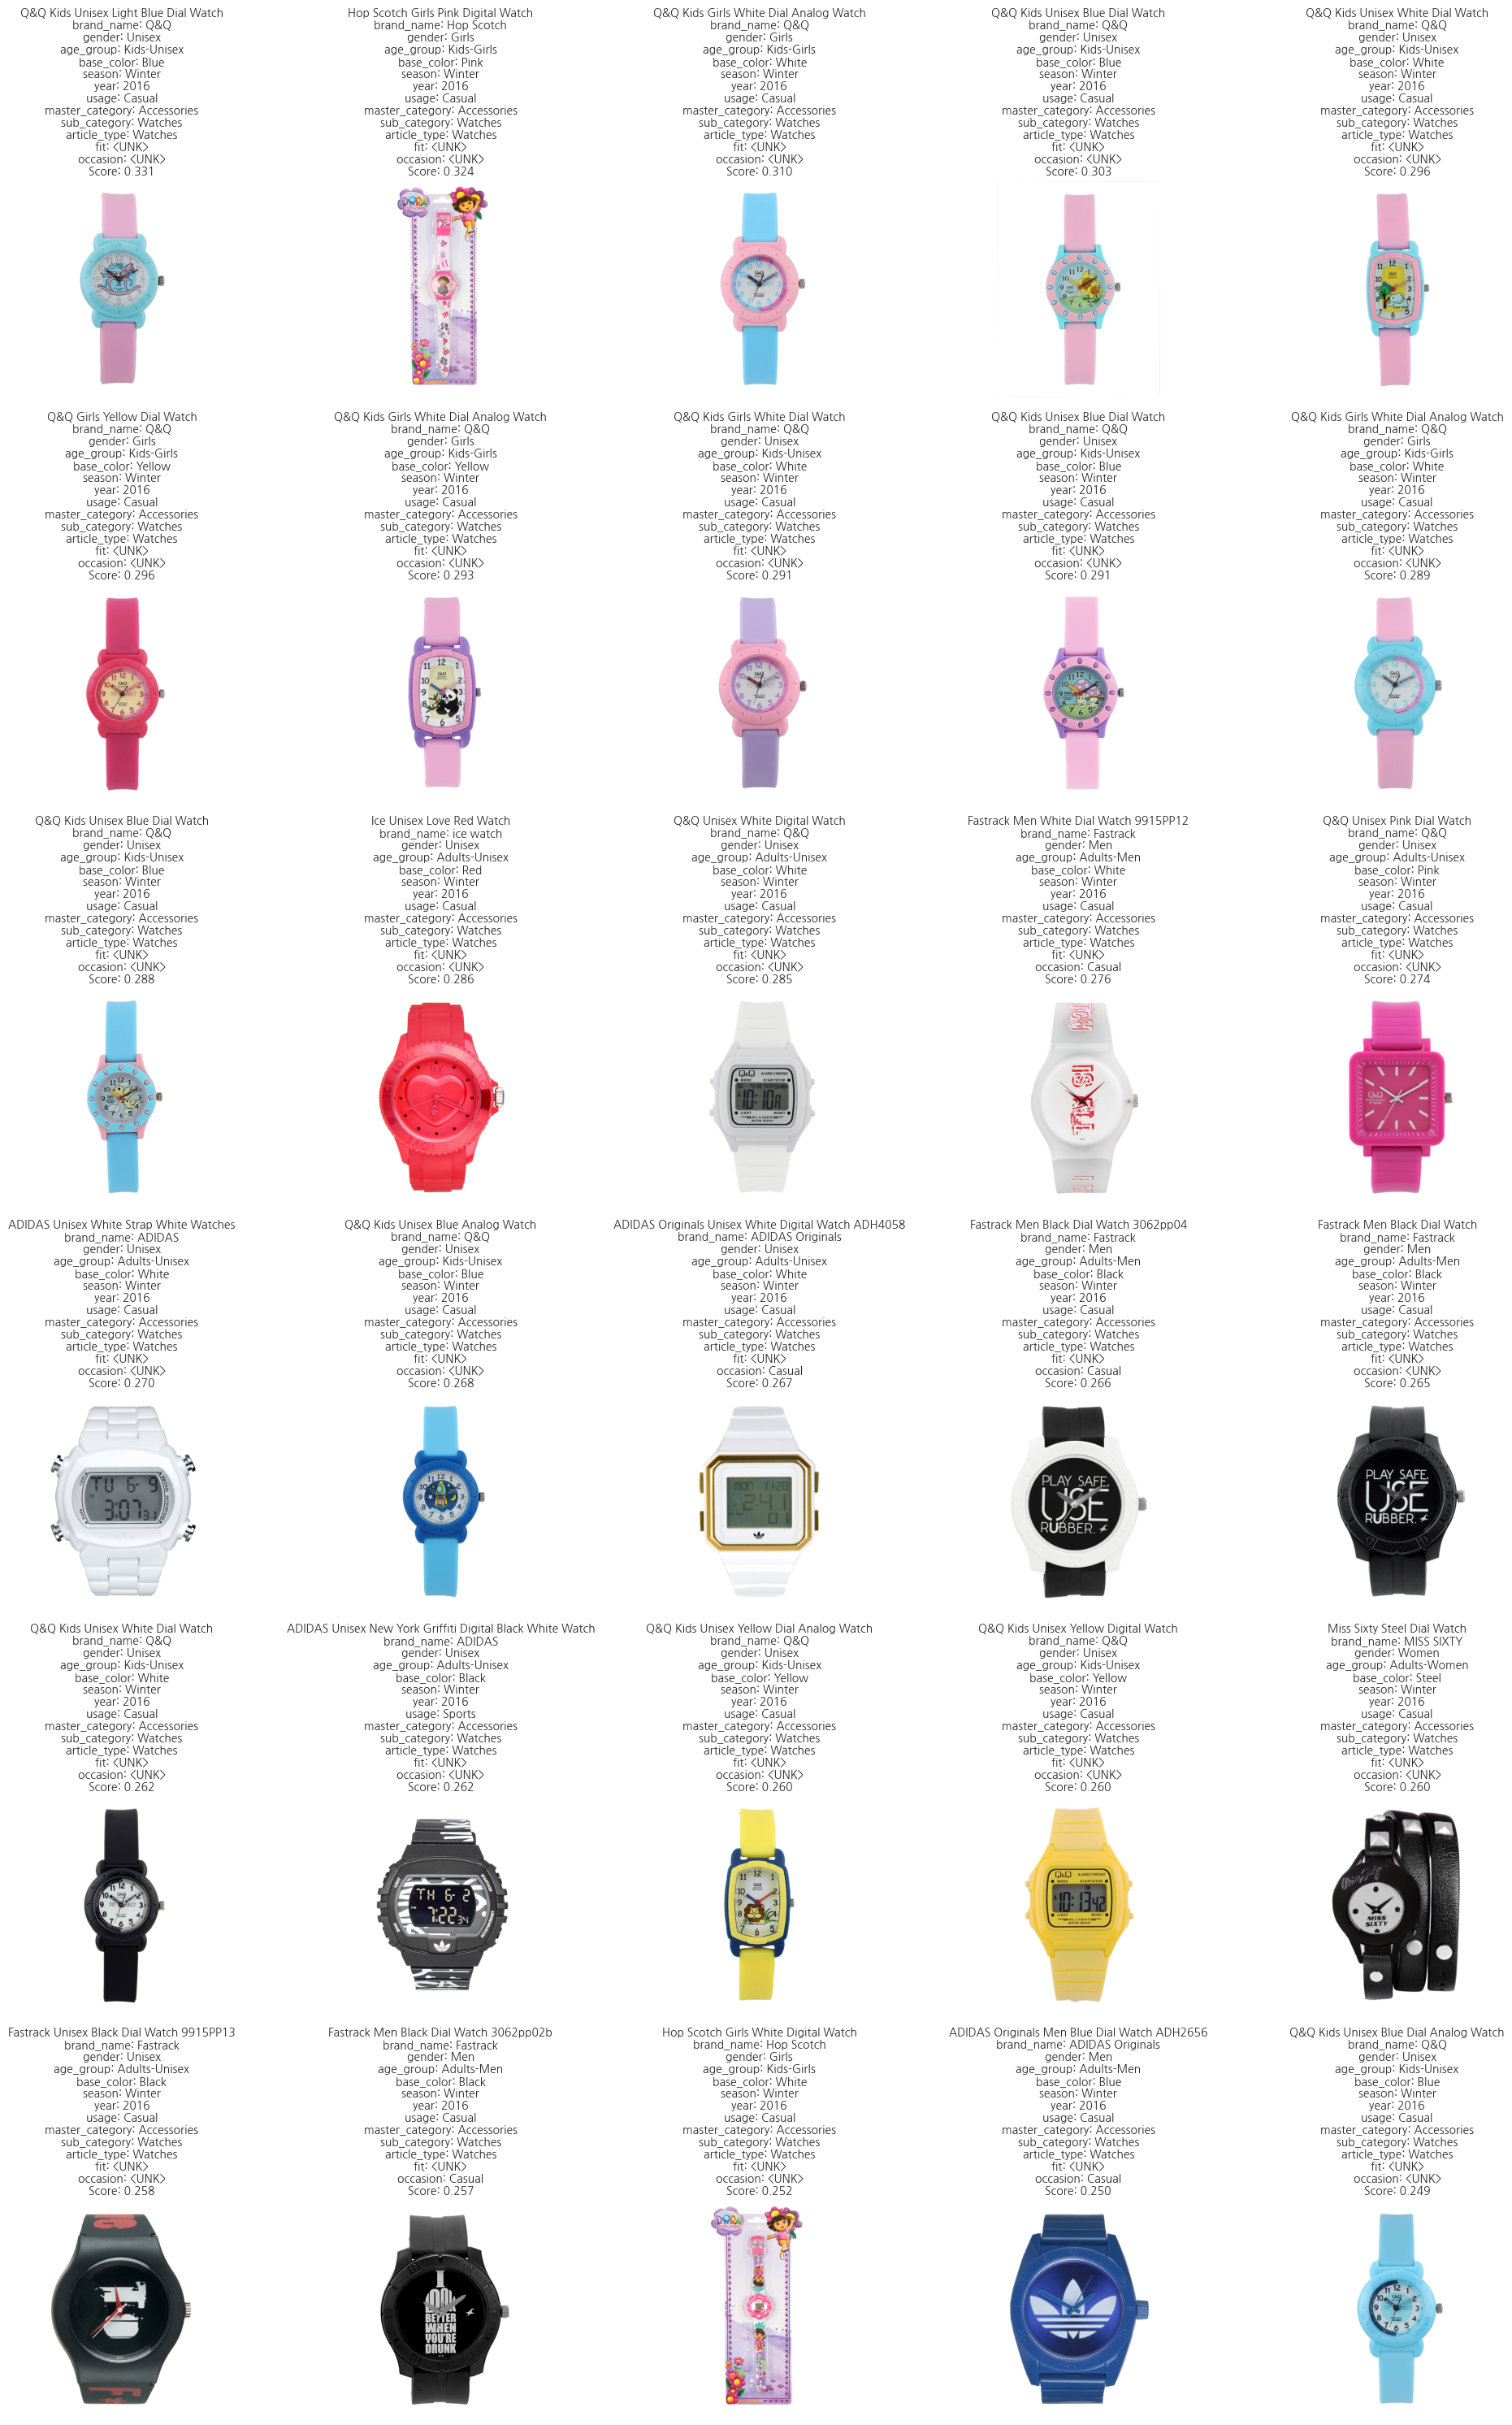

In [12]:
# 추천 아이템 후보군 상세 보기
show_items(
    item_ids=list(recommendation.keys()),
    df_item=df_item,
    attributes=tuple(model.seq_model_config["feature_dims"].keys()),
    scores=list(recommendation.values()),
    image_dir=paths.dataset_dir.joinpath("images"),
)